# Final Project — Face Detection & Demographic Estimation Pipeline

**Course:** Artificial Intelligence — Universidad EAFIT \
**Authors:** Emanuel Serna Ruales & Samuel Andrés Areiza Tabares \
**Platform:** Lightning AI (Tesla T4, 15.6 GB VRAM) 

## Pipeline

```
image → [YOLOv8 fine-tuned on WIDER FACE] → face bboxes
      → crop with 5% padding
      → [ResNet18 multi-task fine-tuned on UTKFace] → (age, gender)
      → annotated visualization
```

## Stages

1. **Environment setup** & GPU check
2. **WIDER FACE** download & verification (Stage-1 dataset)
3. **YOLOv8 fine-tuning** (1 experiment, with augmentation)
4. **Detection metrics** (val + test)
5. **UTKFace** download (Stage-2 dataset)
6. **Multi-task ResNet18** training (age regression + gender classification)
7. **Classifier evaluation** (gender accuracy, age SmoothL1, confusion matrix, error histogram)


---
## Part 0 — Environment Setup

In [1]:
%pip install "ultralytics==8.*" "litserve==0.*" "numpy==1.26.*" \
             "scikit-learn==1.3.2" fastapi uvicorn pillow \
             opencv-python supervision roboflow \
             huggingface_hub datasets seaborn tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import ultralytics

print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.version.cuda}")
print(f"GPU        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")
print(f"Ultralytics: {ultralytics.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch    : 2.8.0+cu128
CUDA       : 12.8
GPU        : Tesla T4
VRAM       : 15.6 GB
Ultralytics: 8.4.56


---
## Fast-resume (skip Parts 1-3 if YOLO is already trained)

If you already have `checkpoints/yolo_face_best.pt` from a previous run and just want to continue with the demographic classifier (Parts 4-7), run the cell below and **skip directly to Part 4**.

If this is a fresh run, **skip this cell and continue normally** to Part 1.

In [1]:
import os, json

FAST_RESUME = True 

if FAST_RESUME:
    yolo_best_path = "checkpoints/yolo_face_best.pt"
    if os.path.exists(yolo_best_path):
        size_mb = os.path.getsize(yolo_best_path) / 1e6
        print(f"Fast-resume enabled.")
        print(f"YOLO checkpoint found: {yolo_best_path} ({size_mb:.1f} MB)")
        print(f"Skip to Part 4 (UTKFace dataset).")
        
        if os.path.exists("yolo_metrics.json"):
            with open("yolo_metrics.json") as f:
                full_metrics = json.load(f)
            print(f"Previous YOLO metrics loaded ({len(full_metrics)} experiment(s))")
        best_name = "exp_auto_aug"
    else:
        print(f"No YOLO checkpoint at {yolo_best_path}. You need to train YOLO first (Parts 1-3).")
else:
    print("Fast-resume disabled — proceed with Parts 1-3 normally.")

Fast-resume enabled.
YOLO checkpoint found: checkpoints/yolo_face_best.pt (22.5 MB)
Skip to Part 4 (UTKFace dataset).
Previous YOLO metrics loaded (1 experiment(s))


---
## Part 1 — WIDER FACE Dataset Download & Verification

We use the WIDER FACE benchmark dataset (Yang et al., CVPR 2016), restructured by Roboflow for direct YOLOv8 compatibility. This is the same workspace (`large-benchmark-datasets`) used in Workshop 2 for the Logistics dataset, ensuring methodological consistency.

In [1]:
from roboflow import Roboflow

rf = Roboflow(api_key='p5xHy6F3xuJnMvBZQkIA')
project = rf.workspace("large-benchmark-datasets").project("wider-face-ndtcz")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [2]:
# ── Diagnostic: inspect what was actually downloaded ──
from pathlib import Path
import subprocess

ds_path = Path(dataset.location)
print(f"Dataset location: {ds_path}")
print(f"Total size      : ", end="", flush=True)
subprocess.run(['du', '-sh', str(ds_path)])

print("\n── Folder structure (images + non-empty labels) ──")
for sub in sorted(ds_path.iterdir()):
    if sub.is_dir():
        imgs = list(sub.rglob("*.jpg")) + list(sub.rglob("*.png"))
        labels = list(sub.rglob("*.txt"))
        # Count NON-EMPTY label files
        non_empty_labels = [l for l in labels if l.stat().st_size > 0]
        print(f"  {sub.name:<10}: {len(imgs):>6} images | "
              f"{len(labels):>6} label files | "
              f"{len(non_empty_labels):>6} non-empty")
    else:
        print(f"  {sub.name}")

# Identify all splits with usable ground truth
print("\n── Splits with usable ground truth (will be POOLED) ──")
usable_splits = []
for split_name in ["train", "valid", "test"]:
    split_dir = ds_path / split_name
    if not split_dir.exists():
        print(f"{split_name}: directory missing — skipping")
        continue
    lbl_dir = split_dir / "labels"
    if not lbl_dir.exists():
        print(f"{split_name}: no labels/ subdir — skipping")
        continue
    non_empty = sum(1 for l in lbl_dir.glob("*.txt") if l.stat().st_size > 0)
    if non_empty > 100:
        print(f"{split_name}: {non_empty:,} annotated pairs — INCLUDED")
        usable_splits.append(split_name)
    else:
        print(f"{split_name}: {non_empty} annotated pairs — too few, excluded")

if not usable_splits:
    raise RuntimeError("No split with usable ground truth found.")

print(f"\n Will pool {len(usable_splits)} split(s): {usable_splits}")

Dataset location: /teamspace/studios/this_studio/WIDER-FACE-1
Total size      : 1.1G	/teamspace/studios/this_studio/WIDER-FACE-1

── Folder structure (images + non-empty labels) ──
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  test      :  12877 images |  12877 label files |  12873 non-empty
  valid     :   3226 images |   3226 label files |   3222 non-empty

── Splits with usable ground truth (will be POOLED) ──
train: directory missing — skipping
valid: 3,222 annotated pairs — INCLUDED
test: 12,873 annotated pairs — INCLUDED

 Will pool 2 split(s): ['valid', 'test']


### Pool and re-split the annotated data

The Roboflow distribution of WIDER FACE ships with both `valid/` (~3,200 images) and `test/` (~12,900 images) annotated with bounding boxes. Rather than discarding either split, we **pool all annotated images** and apply a stratified **80/10/10 re-split** with fixed `seed=42` for reproducibility.

This maximizes available training data (~16K annotated pairs total, up from the ~3K we would have with a single split) while keeping evaluation honest through the seed-based deterministic re-split. The new partitions are documented in the report.

In [4]:
import random
import shutil
from pathlib import Path

random.seed(42)

# Collect (image, label) pairs from all usable splits
all_pairs = []
for split_name in usable_splits:
    src_img_dir = ds_path / split_name / "images"
    src_lbl_dir = ds_path / split_name / "labels"
    n_added = 0
    for img_file in sorted(src_img_dir.iterdir()):
        if img_file.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        lbl_file = src_lbl_dir / (img_file.stem + ".txt")
        if lbl_file.exists() and lbl_file.stat().st_size > 0:
            all_pairs.append((img_file, lbl_file))
            n_added += 1
    print(f"  Pooled {n_added:,} pairs from '{split_name}/'")

print(f"\nTotal annotated pairs pooled: {len(all_pairs):,}")

# Shuffle and split 80/10/10
random.shuffle(all_pairs)
n = len(all_pairs)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

splits = {
    "train": all_pairs[:n_train],
    "valid": all_pairs[n_train:n_train + n_val],
    "test" : all_pairs[n_train + n_val:],
}

# Destination root — clean new structure
NEW_ROOT = Path("/teamspace/studios/this_studio/wider-face-resplit")
if NEW_ROOT.exists():
    shutil.rmtree(NEW_ROOT)

print("\n── Writing re-split to disk ──")
for split_name, items in splits.items():
    img_dst = NEW_ROOT / split_name / "images"
    lbl_dst = NEW_ROOT / split_name / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)
    for img_src, lbl_src in items:
        shutil.copy(img_src, img_dst / img_src.name)
        shutil.copy(lbl_src, lbl_dst / lbl_src.name)
    print(f"  {split_name:<6}: {len(items):>6,} pairs")

# Write a fresh data.yaml for the new split (absolute paths)
new_yaml = NEW_ROOT / "data.yaml"
with open(new_yaml, "w") as f:
    f.write(
        f"train: {NEW_ROOT}/train/images\n"
        f"val:   {NEW_ROOT}/valid/images\n"
        f"test:  {NEW_ROOT}/test/images\n"
        f"nc: 1\n"
        f"names: ['face']\n"
    )

# Override DATA_YAML so the rest of the notebook uses the new split
DATA_YAML = str(new_yaml)
print(f"\n Re-split complete. New DATA_YAML: {DATA_YAML}")

  Pooled 3,222 pairs from 'valid/'


  Pooled 12,873 pairs from 'test/'

Total annotated pairs pooled: 16,095

── Writing re-split to disk ──
  train : 12,876 pairs
  valid :  1,609 pairs
  test  :  1,610 pairs

 Re-split complete. New DATA_YAML: /teamspace/studios/this_studio/wider-face-resplit/data.yaml


In [9]:
import yaml
from pathlib import Path

# DATA_YAML was set by the re-split cell above — read it directly
print(f"Using data.yaml from re-split: {DATA_YAML}")

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print("\n── data.yaml ──────────────────────────────")
for k, v in cfg.items():
    print(f"  {k:<10}: {v}")

# Count images per split
print("\n── Image counts ────────────────────────────")
for split in ["train", "valid", "test"]:
    key = "val" if split == "valid" else split
    rel = cfg.get(split, cfg.get(key, ""))
    # Absolute path in new data.yaml
    split_path = Path(rel)
    if split_path.exists():
        n = len(list(split_path.glob("*.jpg")) + list(split_path.glob("*.png")))
        print(f"  {split:<8}: {n:,} images")

Using data.yaml from re-split: /teamspace/studios/this_studio/wider-face-resplit/data.yaml

── data.yaml ──────────────────────────────
  train     : /teamspace/studios/this_studio/wider-face-resplit/train/images
  val       : /teamspace/studios/this_studio/wider-face-resplit/valid/images
  test      : /teamspace/studios/this_studio/wider-face-resplit/test/images
  nc        : 1
  names     : ['face']

── Image counts ────────────────────────────
  train   : 12,876 images
  valid   : 1,609 images
  test    : 1,610 images


---
## Part 2 — Fine-tune YOLOv8 on WIDER FACE

### Single-experiment configuration

We run a **single training experiment** using the augmentation configuration that gave the best results in Workshop 2 (`auto_augment='autoaugment'`). Instead of performing multiple augmentation ablations, the project focuses on optimizing a single well-justified setup and integrating it into the complete end-to-end pipeline (Stages 1 + 2).

| Name            | Batch | translate | scale | auto_augment  | Rationale |
|-----------------|-------|-----------|-------|---------------|-----------|
| `exp_auto_aug`  | 8     | 0.1       | 0.5   | `autoaugment` | Strong augmentation policy with improved VRAM stability during training |

**Parameter rationale:**
- `translate=0.1` shifts the image up to 10%, helping the detector generalize when faces appear slightly displaced or near image borders.
- `scale=0.5` randomly rescales objects to improve robustness across different face sizes, which is especially important for WIDER FACE due to its large scale variation and tiny crowded faces.
- `auto_augment='autoaugment'` applies a learned augmentation policy including geometric and photometric transformations that improve generalization.
- `batch=8` provides stable GPU memory usage at `imgsz=768`, avoiding CUDA out-of-memory issues and preventing `TaskAlignedAssigner` fallback to CPU during training.
- `imgsz=768` increases spatial resolution, improving detection performance on small and distant faces.
- `epochs=40` with `patience=15` allow the model additional convergence time while still enabling early stopping if validation performance saturates.

In [14]:
from ultralytics import YOLO
from pathlib import Path
import time, json

# ── Shared base hyperparameters ───────────────────────────────────────────────
BASE = dict(
    data          = DATA_YAML,
    model         = "yolov8s.pt",
    epochs        = 40,
    imgsz         = 768,
    optimizer     = "AdamW",
    lr0           = 5e-4,
    lrf           = 1e-2,
    cos_lr        = True,
    warmup_epochs = 2,
    mosaic        = 0.5,
    fliplr        = 0.5,
    flipud        = 0.0,
    hsv_h         = 0.015,
    hsv_s         = 0.5,
    hsv_v         = 0.3,
    patience      = 15,
    project       = "runs/face",
    exist_ok      = True,
    seed          = 42,
    verbose       = False,
    plots         = True,
    device        = 0,
)

EXPERIMENTS = [
    dict(name="exp_auto_aug", batch=8, translate=0.1, scale=0.5, auto_augment="autoaugment"),
]

exp = EXPERIMENTS[0]
print(f"Running 1 experiment: {exp['name']}")
print(f"  batch={exp['batch']}  translate={exp['translate']}  scale={exp['scale']}  "
      f"auto_augment={exp.get('auto_augment', 'disabled')}")
print(f"\nFixed: model=yolov8s · epochs=40 · AdamW · lr0=5e-4 · imgsz=768 · patience=15")

Running 1 experiment: exp_auto_aug
  batch=8  translate=0.1  scale=0.5  auto_augment=autoaugment

Fixed: model=yolov8s · epochs=40 · AdamW · lr0=5e-4 · imgsz=768 · patience=15


### Run the experiment

In [15]:
import json
import time
import yaml
from pathlib import Path
from ultralytics import YOLO

# ── Verify data.yaml ─────────────────────────────────────────────
print(f"Using data.yaml: {DATA_YAML}")

with open(DATA_YAML) as f:
    cfg_yaml = yaml.safe_load(f)

print("\n── data.yaml ──────────────────────────────")
for k, v in cfg_yaml.items():
    print(f"  {k:<10}: {v}")

# Quick validation of dataset paths
for split in ["train", "val", "test"]:
    split_path = Path(cfg_yaml.get(split, ""))
    
    if not split_path.exists():
        raise FileNotFoundError(f"Split path does not exist: {split_path}")

    n_imgs = len(list(split_path.glob("*.jpg")) +
                 list(split_path.glob("*.png")))

    print(f"  {split:<8}: {n_imgs:,} images")

# ── Training ────────────────────────────────────────────────────
training_results = {}

for i, exp in enumerate(EXPERIMENTS, 1):
    name = exp["name"]
    cfg  = {**BASE, **exp}

    print(f"\n{'='*65}")
    print(f"  Training — {name}")
    print(f"  batch={cfg['batch']}  "
          f"translate={cfg['translate']}  "
          f"scale={cfg['scale']}  "
          f"auto_augment={cfg.get('auto_augment', 'disabled')}")
    print(f"{'='*65}")

    model = YOLO(cfg["model"])

    t0 = time.time()
    results = model.train(**cfg)
    elapsed = (time.time() - t0) / 3600

    # Save best weights info
    save_dir = Path(results.save_dir)
    best_pt  = save_dir / "weights" / "best.pt"

    training_results[name] = {
        "save_dir": str(save_dir),
        "best_pt": str(best_pt),
        "elapsed_h": elapsed,
        "metrics": results.results_dict,
    }

    print(f"\n  Done in {elapsed:.2f}h")
    print(f"    mAP@50    : {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
    print(f"    mAP@50:95 : {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")
    print(f"    Precision : {results.results_dict.get('metrics/precision(B)', 0):.4f}")
    print(f"    Recall    : {results.results_dict.get('metrics/recall(B)', 0):.4f}")

# ── Save summary ────────────────────────────────────────────────
with open("training_results.json", "w") as f:
    json.dump(
        {
            k: {kk: vv for kk, vv in v.items() if kk != "metrics"}
            for k, v in training_results.items()
        },
        f,
        indent=2
    )

print("\nSaved training_results.json")

Using data.yaml: /teamspace/studios/this_studio/wider-face-resplit/data.yaml

── data.yaml ──────────────────────────────
  train     : /teamspace/studios/this_studio/wider-face-resplit/train/images
  val       : /teamspace/studios/this_studio/wider-face-resplit/valid/images
  test      : /teamspace/studios/this_studio/wider-face-resplit/test/images
  nc        : 1
  names     : ['face']
  train   : 12,876 images
  val     : 1,609 images
  test    : 1,610 images

  Training — exp_auto_aug
  batch=8  translate=0.1  scale=0.5  auto_augment=autoaugment


Ultralytics 8.4.56 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=autoaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/teamspace/studios/this_studio/wider-face-resplit/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=exp_auto_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

---
## Part 3 — Validation & Detection Metrics

Both val and test splits are evaluated for each experiment.

In [16]:
def validate_model(weights_path: str, data_yaml: str, split: str = "val") -> dict:
    """Run YOLO val and return per-class + overall metrics."""
    model = YOLO(weights_path)
    res = model.val(data=data_yaml, split=split, verbose=False, plots=False)

    # Overall metrics
    overall = dict(
        mAP50     = float(res.box.map50),
        mAP50_95  = float(res.box.map),
        Precision = float(res.box.mp),
        Recall    = float(res.box.mr),
    )
    overall["F1"] = (2 * overall["Precision"] * overall["Recall"] /
                    (overall["Precision"] + overall["Recall"] + 1e-9))

    # Per-class metrics
    names = res.names
    per_class = {}
    for i, ap50 in enumerate(res.box.ap50):
        cls_name = names[i] if i in names else f"cls_{i}"
        p, r = float(res.box.p[i]), float(res.box.r[i])
        per_class[cls_name] = dict(
            AP50    = float(ap50),
            AP50_95 = float(res.box.ap[i].mean()) if hasattr(res.box.ap[i], 'mean') else float(res.box.ap[i]),
            Prec    = p,
            Rec     = r,
            F1      = 2 * p * r / (p + r + 1e-9),
        )

    return dict(overall=overall, per_class=per_class)


def print_metrics(name: str, m: dict, split: str):
    """Pretty-print metrics from validate_model() output."""
    o = m["overall"]
    print(f"\n── {name}  [{split}] ────────────────────────────")
    print(f"   mAP50       : {o['mAP50']:.4f}")
    print(f"   mAP50_95    : {o['mAP50_95']:.4f}")
    print(f"   Precision   : {o['Precision']:.4f}")
    print(f"   Recall      : {o['Recall']:.4f}")
    print(f"   F1          : {o['F1']:.4f}")

    print(f"\n   {'Class':<22}    {'AP50':>6}   {'AP50:95':>7}   {'Prec':>5}   {'Rec':>5}   {'F1':>5}")
    print("   " + "-" * 60)
    for cls, mm in m["per_class"].items():
        print(f"   {cls:<22}  {mm['AP50']:>7.4f}  {mm['AP50_95']:>8.4f}  {mm['Prec']:>6.4f}  {mm['Rec']:>6.4f}  {mm['F1']:>6.4f}")

In [17]:
full_metrics = {}

for name, r in training_results.items():
    full_metrics[name] = {}
    for split in ["val", "test"]:
        m = validate_model(r["best_pt"], DATA_YAML, split=split)
        full_metrics[name][split] = m
        print_metrics(name, m, split)

with open("yolo_metrics.json", "w") as f:
    json.dump(full_metrics, f, indent=2)
print("\nFull metrics saved to yolo_metrics.json")

Ultralytics 8.4.56 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1790.2±388.9 MB/s, size: 58.0 KB)
val: Scanning /teamspace/studios/this_studio/wider-face-resplit/valid/labels.cache... 1609 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1609/1609 449.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 3.7it/s 27.6s0.3s
                   all       1609      19097      0.867      0.639      0.716      0.393
Speed: 1.6ms preprocess, 11.8ms inference, 0.0ms loss, 1.1ms postprocess per image

── exp_auto_aug  [val] ────────────────────────────
   mAP50       : 0.7163
   mAP50_95    : 0.3929
   Precision   : 0.8670
   Recall      : 0.6386
   F1          : 0.7355

   Class                       AP50   AP50:95    Prec     Rec      F1
   ------------------------------

### Detection metrics — val + test

In [18]:
# Print compact val/test summary
exp_name = list(full_metrics.keys())[0]
val_m  = full_metrics[exp_name]["val"]["overall"]
test_m = full_metrics[exp_name]["test"]["overall"]

print(f"{'Split':<8} {'mAP50':>7} {'mAP50:95':>10} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 52)
print(f"  {'val':<6} {val_m['mAP50']:>7.4f} {val_m['mAP50_95']:>10.4f} "
      f"{val_m['Precision']:>7.4f} {val_m['Recall']:>7.4f} {val_m['F1']:>7.4f}")
print(f"  {'test':<6} {test_m['mAP50']:>7.4f} {test_m['mAP50_95']:>10.4f} "
      f"{test_m['Precision']:>7.4f} {test_m['Recall']:>7.4f} {test_m['F1']:>7.4f}")

best_name = exp_name  # only one experiment, so it's the "best" by default

Split      mAP50   mAP50:95    Prec     Rec      F1
----------------------------------------------------
  val     0.7163     0.3929  0.8670  0.6386  0.7355
  test    0.7420     0.4088  0.8786  0.6683  0.7592


In [19]:
# Persist best YOLO weights to a clean location for downstream use
import shutil, os
os.makedirs("checkpoints", exist_ok=True)
yolo_best_path = "checkpoints/yolo_face_best.pt"
shutil.copy(training_results[best_name]["best_pt"], yolo_best_path)
print(f"Saved YOLO best weights → {yolo_best_path}")

Saved YOLO best weights → checkpoints/yolo_face_best.pt


---
## Part 4 — UTKFace Dataset (Stage-2)

UTKFace (Zhang et al., CVPR 2017) provides ~10K aligned and cropped face images annotated with age (0–116), gender (binary), and ethnicity. Labels are embedded in filenames: `[age]_[gender]_[race]_[datetime].jpg`.

We use the HuggingFace mirror `Subh775/UTKFace_demographics_V1` for reliable streaming download.

In [2]:
from datasets import load_dataset

# Load the dataset — this downloads + caches the parquet shards on first run (~880 MB)
utk_ds = load_dataset("Subh775/UTKFace_demographics_V1", split="train")
print(f"UTKFace loaded: {len(utk_ds):,} rows")
print(f"Columns: {utk_ds.column_names}")
print(f"First sample: age={utk_ds[0]['age']}, gender={utk_ds[0]['gender']}, race={utk_ds[0]['race']}")
print(f"Image type   : {type(utk_ds[0]['image'])}  size={utk_ds[0]['image'].size}")

UTKFace loaded: 10,135 rows
Columns: ['image', 'age', 'gender', 'race']
First sample: age=100, gender=1, race=0
Image type   : <class 'PIL.JpegImagePlugin.JpegImageFile'>  size=(450, 470)


In [3]:
import numpy as np

valid_indices = []
for i, row in enumerate(utk_ds):
    age, gender = int(row["age"]), int(row["gender"])
    if 1 <= age <= 100:
        valid_indices.append((i, age, gender))

print(f"Valid samples after filtering : {len(valid_indices):,}")
print(f"Example index/age/gender      : {valid_indices[0]}")

ages    = np.array([s[1] for s in valid_indices])
genders = np.array([s[2] for s in valid_indices])
print(f"\nAge range   : [{ages.min()}, {ages.max()}]   mean={ages.mean():.1f}   median={np.median(ages):.0f}")
print(f"Gender ratio: male={(genders==0).mean()*100:.1f}%   female={(genders==1).mean()*100:.1f}%")
print(f"\nImages stay in the Parquet cache (memory-mapped).")

Valid samples after filtering : 10,131
Example index/age/gender      : (0, 100, 1)

Age range   : [1, 100]   mean=28.9   median=24
Gender ratio: male=44.8%   female=55.2%

Images stay in the Parquet cache (memory-mapped).


---
## Part 5 — Multi-task ResNet18 (Age regression + Gender classification)

### Architecture

A single ResNet18 backbone (ImageNet-pretrained) shared between two task heads:
- **Age head**: `nn.Dropout(0.2)` → `nn.Linear(512, 1)` → regression in years (loss: SmoothL1 / Huber).
- **Gender head**: `nn.Dropout(0.2)` → `nn.Linear(512, 1)` → binary logit (loss: BCEWithLogits).

The combined loss is `L = α · SmoothL1_age + β · BCE_gender` with `α=0.1, β=1.0`. The age loss is scaled down because its raw magnitude (~5–10 years) is much larger than BCE (~0.3–0.7); without weighting, age would dominate gradients and gender accuracy would stay near chance.

In [40]:
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader


class UTKFaceDataset(Dataset):
    """Lazy-loading wrapper around the HuggingFace Parquet dataset.

    Stores only indices + labels in memory; the PIL image is fetched from
    the memory-mapped Parquet cache on each __getitem__ call. This keeps
    RAM usage near zero regardless of dataset size.
    """
    def __init__(self, hf_dataset, index_samples, transform=None):
        self.hf_dataset = hf_dataset
        self.samples = index_samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        parquet_idx, age, gender = self.samples[idx]
        img = self.hf_dataset[parquet_idx]["image"].convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(age, dtype=torch.float32), torch.tensor(gender, dtype=torch.float32)


class MultiTaskResNet18(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        in_feat = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.dropout = nn.Dropout(p=dropout)
        self.age_head    = nn.Linear(in_feat, 1)
        self.gender_head = nn.Linear(in_feat, 1)
    def forward(self, x):
        feat = self.dropout(self.backbone(x))
        age = self.age_head(feat).squeeze(-1)
        gender_logit = self.gender_head(feat).squeeze(-1)
        return age, gender_logit

print("Defined lazy-loading UTKFaceDataset & MultiTaskResNet18")

Defined lazy-loading UTKFaceDataset & MultiTaskResNet18


### Dataset splits and dataloaders

We split 80/10/10 (train/val/test) with a fixed seed for reproducibility. Different transforms are applied to train vs val/test via separate `UTKFaceDataset` instances over disjoint sample lists (cleaner than wrapping `Subset`).

In [41]:
import random
import gc
import torch
from torch.utils.data import WeightedRandomSampler

# ── Sanitize device state before training Stage 2 ──
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    device = "cuda"
    print(f"  Using GPU: {torch.cuda.get_device_name(0)}")
    free_vram = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
    print(f"  Free VRAM: {free_vram:.2f} GB")
else:
    device = "cpu"
    print("No GPU detected — falling back to CPU (much slower).")

# Quick RAM check
import psutil
ram_total = psutil.virtual_memory().total / 1e9
ram_free  = psutil.virtual_memory().available / 1e9
print(f"  RAM       : {ram_free:.1f} GB free / {ram_total:.1f} GB total")

# ── Fixed-seed shuffle of the index list ──
rng = random.Random(42)
rng.shuffle(valid_indices)

n = len(valid_indices)
n_train, n_val = int(0.8 * n), int(0.1 * n)
idx_train = valid_indices[:n_train]
idx_val   = valid_indices[n_train:n_train + n_val]
idx_test  = valid_indices[n_train + n_val:]

print(f"\nTrain: {len(idx_train):,}   Val: {len(idx_val):,}   Test: {len(idx_test):,}")

# ── Transforms ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Pass the utk_ds (HuggingFace dataset) so __getitem__ can fetch images lazily
train_ds = UTKFaceDataset(utk_ds, idx_train, transform=train_tf)
val_ds   = UTKFaceDataset(utk_ds, idx_val,   transform=eval_tf)
test_ds  = UTKFaceDataset(utk_ds, idx_test,  transform=eval_tf)

ages_train = np.array([s[1] for s in idx_train])
bin_edges  = np.arange(0, 101, 10)
bin_idx    = np.clip(np.digitize(ages_train, bin_edges) - 1, 0, len(bin_edges) - 2)
bin_counts = np.bincount(bin_idx, minlength=len(bin_edges) - 1).astype(float)
bin_counts[bin_counts == 0] = 1
sample_weights = torch.tensor((1.0 / bin_counts)[bin_idx], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

if device == "cuda":
    BATCH       = 64
    NUM_WORKERS = 0          
    PIN_MEMORY  = True
else:
    BATCH       = 16
    NUM_WORKERS = 0
    PIN_MEMORY  = False

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"\nDataloaders ready  (device={device}, batch={BATCH}, workers={NUM_WORKERS})")
print(f"  Memory strategy: lazy loading from Parquet cache (RAM-friendly)")

  Using GPU: Tesla T4
  Free VRAM: 15.40 GB
  RAM       : 9.2 GB free / 16.6 GB total

Train: 8,104   Val: 1,013   Test: 1,014

Dataloaders ready  (device=cuda, batch=64, workers=0)
  Memory strategy: lazy loading from Parquet cache (RAM-friendly)


### Training loop

- Optimizer: AdamW, `lr=1e-4`, `weight_decay=1e-4`
- Scheduler: Cosine annealing across 25 epochs
- Loss weights: `α=0.1` for age (SmoothL1), `β=1.0` for gender (BCE)
- Early-best checkpointing on val combined loss

In [49]:
from tqdm import tqdm

model = MultiTaskResNet18(pretrained=True).to(device)

LR        = 1e-4
EPOCHS    = 20
AGE_W     = 0.1
GENDER_W  = 1.0

smoothl1 = nn.SmoothL1Loss()
bce = nn.BCEWithLogitsLoss()

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

import os
os.makedirs("checkpoints", exist_ok=True)
CKPT_PATH = "checkpoints/demographic_resnet18.pt"

best_val_loss = float("inf")
history = []

for epoch in range(EPOCHS):
    # ─── Train ───
    model.train()
    tr_loss, tr_age_smoothl1, tr_gender_correct, n_tr = 0.0, 0.0, 0, 0
    for x, age, gender in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]", leave=False):
        x, age, gender = x.to(device), age.to(device), gender.to(device)

        opt.zero_grad()
        with torch.amp.autocast('cuda'):
            pred_age, pred_g_logit = model(x)
            l_age = smoothl1(pred_age, age)
            l_g = bce(pred_g_logit, gender)
            loss = AGE_W * l_age + GENDER_W * l_g
        loss.backward()
        opt.step()

        bs = x.size(0)
        tr_loss          += loss.item() * bs
        tr_age_smoothl1 += l_age.item() * bs
        tr_gender_correct += ((torch.sigmoid(pred_g_logit) > 0.5).float() == gender).float().sum().item()
        n_tr             += bs

    # ─── Val ───
    model.eval()
    va_loss, va_age_smoothl1, va_gender_correct, n_va = 0.0, 0.0, 0, 0
    with torch.no_grad():
        for x, age, gender in val_loader:
            x, age, gender = x.to(device), age.to(device), gender.to(device)
            with torch.amp.autocast('cuda'):
                pred_age, pred_g_logit = model(x)
                l_age = smoothl1(pred_age, age)
                l_g = bce(pred_g_logit, gender)
                loss = AGE_W * l_age + GENDER_W * l_g

            bs = x.size(0)
            va_loss           += loss.item() * bs
            va_age_smoothl1        += l_age.item() * bs
            va_gender_correct += ((torch.sigmoid(pred_g_logit) > 0.5).float() == gender).float().sum().item()
            n_va              += bs

    sched.step()

    log = dict(
        epoch=epoch + 1,
        train_loss       = tr_loss / n_tr,
        val_loss         = va_loss / n_va,
        train_age_smoothl1    = tr_age_smoothl1 / n_tr,
        val_age_smoothl1      = va_age_smoothl1 / n_va,
        train_gender_acc = tr_gender_correct / n_tr,
        val_gender_acc   = va_gender_correct / n_va,
        lr               = sched.get_last_lr()[0],
    )
    history.append(log)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"train_loss={log['train_loss']:.4f} val_loss={log['val_loss']:.4f} | "
          f"age_smoothl1_val={log['val_age_smoothl1']:.2f}y | gender_acc_val={log['val_gender_acc']:.4f}")

    if log["val_loss"] < best_val_loss:
        best_val_loss = log["val_loss"]
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"   Saved best → {CKPT_PATH}")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch 1/20 [train]:   4%|▍         | 5/127 [00:04<01:46,  1.15it/s]

Epoch  1/20 | train_loss=4.8175 val_loss=2.5468 | age_smoothl1_val=22.68y | gender_acc_val=0.8707
   Saved best → checkpoints/demographic_resnet18.pt


Epoch  2/20 | train_loss=4.0007 val_loss=2.0374 | age_smoothl1_val=17.88y | gender_acc_val=0.8904
   Saved best → checkpoints/demographic_resnet18.pt


Epoch  3/20 | train_loss=3.2601 val_loss=1.6732 | age_smoothl1_val=14.24y | gender_acc_val=0.8875
   Saved best → checkpoints/demographic_resnet18.pt


Epoch  4/20 | train_loss=2.5446 val_loss=1.3676 | age_smoothl1_val=11.26y | gender_acc_val=0.8954
   Saved best → checkpoints/demographic_resnet18.pt


...

Epoch 16/20 | train_loss=0.3550 val_loss=0.7039 | age_smoothl1_val=4.81y | gender_acc_val=0.9092
   Saved best → checkpoints/demographic_resnet18.pt


Epoch 17/20 | train_loss=0.3379 val_loss=0.7037 | age_smoothl1_val=4.77y | gender_acc_val=0.9082
   Saved best → checkpoints/demographic_resnet18.pt


Epoch 18/20 | train_loss=0.3240 val_loss=0.7097 | age_smoothl1_val=4.79y | gender_acc_val=0.9072


Epoch 19/20 | train_loss=0.3354 val_loss=0.7006 | age_smoothl1_val=4.75y | gender_acc_val=0.9102
   Saved best → checkpoints/demographic_resnet18.pt


Epoch 20/20 | train_loss=0.3249 val_loss=0.7129 | age_smoothl1_val=4.85y | gender_acc_val=0.9092

Training complete. Best val loss: 0.7006


### Training curves

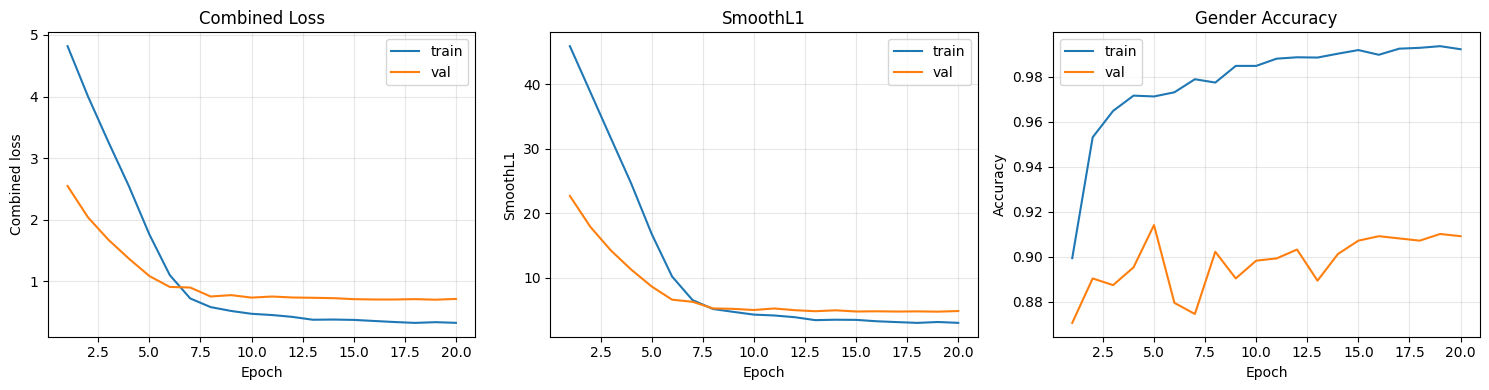

In [50]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, [h["train_loss"] for h in history], label="train")
axes[0].plot(epochs, [h["val_loss"]   for h in history], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Combined loss")
axes[0].set_title("Combined Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [h["train_age_smoothl1"] for h in history], label="train")
axes[1].plot(epochs, [h["val_age_smoothl1"]   for h in history], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("SmoothL1")
axes[1].set_title("SmoothL1"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, [h["train_gender_acc"] for h in history], label="train")
axes[2].plot(epochs, [h["val_gender_acc"]   for h in history], label="val")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Gender Accuracy"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 6 — Classifier Evaluation (Test set)

We load the best checkpoint and run a single pass over the held-out test set, then compute:
- **Gender**: accuracy, confusion matrix, per-class precision/recall/F1.
- **Age**: MAE, error histogram, predicted vs true scatter.

In [51]:
import json
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

all_age_true, all_age_pred = [], []
all_g_true,   all_g_pred   = [], []

with torch.no_grad():
    for x, age, gender in tqdm(test_loader, desc="Test inference"):
        x = x.to(device)
        pred_age, pred_g_logit = model(x)
        all_age_true.extend(age.numpy().tolist())
        all_age_pred.extend(pred_age.cpu().numpy().tolist())
        all_g_true.extend(gender.numpy().astype(int).tolist())
        all_g_pred.extend((torch.sigmoid(pred_g_logit) > 0.5).cpu().numpy().astype(int).tolist())

all_age_true = np.array(all_age_true)
all_age_pred = np.clip(np.array(all_age_pred), 0, 100)
all_g_true   = np.array(all_g_true)
all_g_pred   = np.array(all_g_pred)

age_mae    = float(np.mean(np.abs(all_age_true - all_age_pred)))
age_rmse   = float(np.sqrt(np.mean((all_age_true - all_age_pred) ** 2)))
gender_acc = float(np.mean(all_g_true == all_g_pred))

print(f"\n── Test set results ──")
print(f"  Age MAE        : {age_mae:.2f} years")
print(f"  Age RMSE       : {age_rmse:.2f} years")
print(f"  Gender Accuracy: {gender_acc:.4f}")
print()
print(classification_report(all_g_true, all_g_pred, target_names=["Male", "Female"]))

# Persist metrics
classifier_metrics = dict(
    test=dict(age_mae=age_mae, age_rmse=age_rmse, gender_accuracy=gender_acc),
    history=history,
    hyperparameters=dict(lr=LR, batch=BATCH, epochs=EPOCHS, age_w=AGE_W, gender_w=GENDER_W),
)
with open("classifier_metrics.json", "w") as f:
    json.dump(classifier_metrics, f, indent=2)
print("\nSaved classifier_metrics.json")

Test inference:   0%|          | 0/16 [00:00<?, ?it/s]

Test inference: 100%|██████████| 16/16 [00:11<00:00,  1.40it/s]


── Test set results ──
  Age MAE        : 5.60 years
  Age RMSE       : 8.89 years
  Gender Accuracy: 0.8984

              precision    recall  f1-score   support

        Male       0.87      0.89      0.88       434
      Female       0.92      0.90      0.91       580

    accuracy                           0.90      1014
   macro avg       0.90      0.90      0.90      1014
weighted avg       0.90      0.90      0.90      1014


Saved classifier_metrics.json


### Diagnostic plots

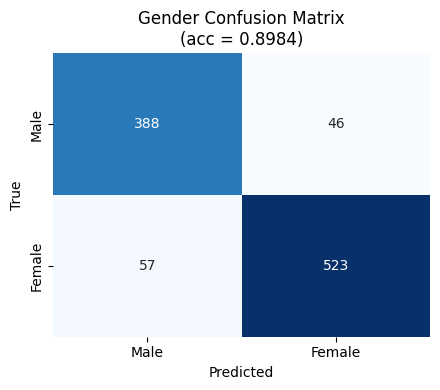

In [52]:
# Confusion matrix
cm = confusion_matrix(all_g_true, all_g_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Gender Confusion Matrix\n(acc = {gender_acc:.4f})")
plt.tight_layout()
plt.savefig("results/confusion_matrix_gender.png", dpi=150, bbox_inches="tight")
plt.show()

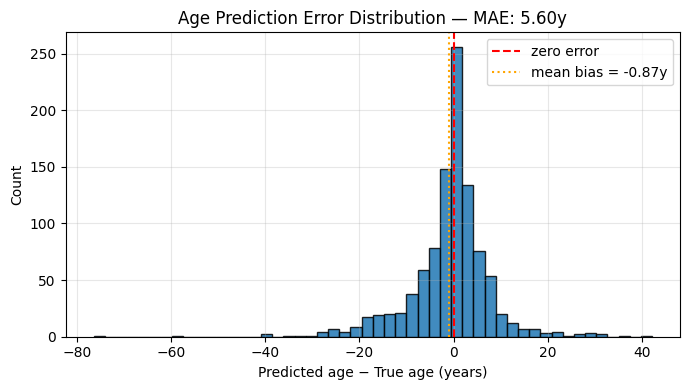

In [53]:
# Age error histogram
errors = all_age_pred - all_age_true
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=50, edgecolor="black", alpha=0.85)
plt.axvline(0, color="red", linestyle="--", label="zero error")
plt.axvline(errors.mean(), color="orange", linestyle=":", label=f"mean bias = {errors.mean():+.2f}y")
plt.xlabel("Predicted age − True age (years)")
plt.ylabel("Count")
plt.title(f"Age Prediction Error Distribution — MAE: {age_mae:.2f}y")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/age_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

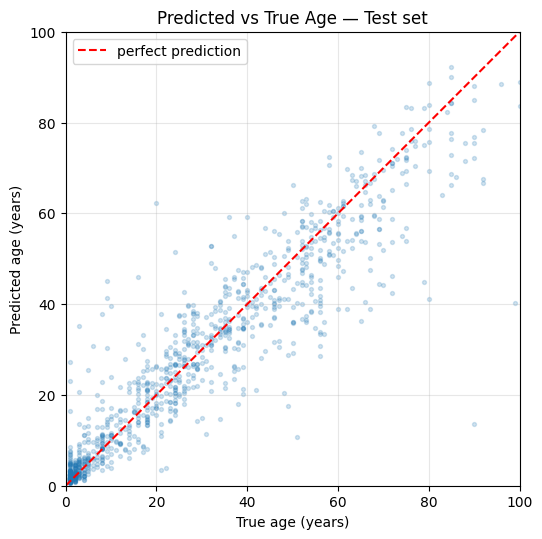

In [54]:
# Predicted vs true age scatter
plt.figure(figsize=(5.5, 5.5))
plt.scatter(all_age_true, all_age_pred, alpha=0.2, s=8)
plt.plot([0, 100], [0, 100], "r--", label="perfect prediction")
plt.xlabel("True age (years)")
plt.ylabel("Predicted age (years)")
plt.title("Predicted vs True Age — Test set")
plt.xlim(0, 100); plt.ylim(0, 100); plt.gca().set_aspect("equal")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/age_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

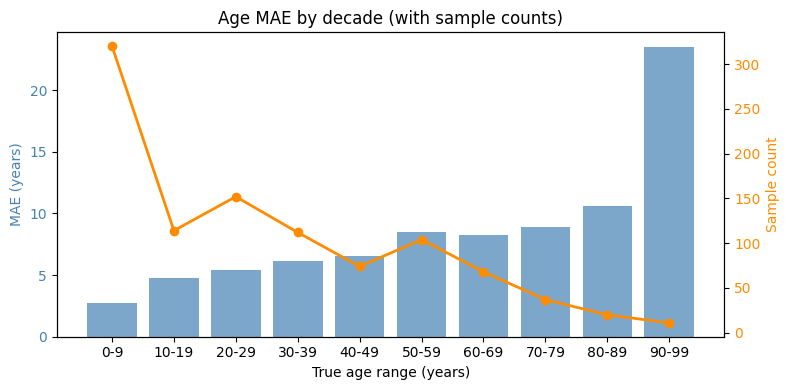

In [55]:
# Age MAE broken down by age decade — reveals where the model struggles
bins = np.arange(0, 101, 10)
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]
mae_by_bin = []
counts = []
for i in range(len(bins) - 1):
    mask = (all_age_true >= bins[i]) & (all_age_true < bins[i+1])
    if mask.sum() > 0:
        mae_by_bin.append(np.mean(np.abs(all_age_pred[mask] - all_age_true[mask])))
        counts.append(int(mask.sum()))
    else:
        mae_by_bin.append(0); counts.append(0)

fig, ax1 = plt.subplots(figsize=(8, 4))
bars = ax1.bar(labels, mae_by_bin, alpha=0.7, color="steelblue")
ax1.set_xlabel("True age range (years)")
ax1.set_ylabel("MAE (years)", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(labels, counts, color="darkorange", marker="o", linewidth=2, label="N samples")
ax2.set_ylabel("Sample count", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")

plt.title("Age MAE by decade (with sample counts)")
fig.tight_layout()
plt.savefig("results/age_mae_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()